# Citi Bike Pickup Demand: Exploratory Data Analysis

This notebook explores hourly pickup demand for the 25 busiest Citi Bike stations during April 2026.

## Goals

- Validate the processed dataset
- Identify the busiest stations
- Examine hourly and weekly demand patterns
- Look for issues that could affect forecasting

In [1]:
from pathlib import Path

Path.cwd()

WindowsPath('c:/Users/Sean/Projects/citi-bike-forecast/notebooks')

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import geopandas as gpd


PROJECT_ROOT = Path.cwd().parent
DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hourly_pickups.parquet"
)

pickups = pd.read_parquet(DATA_FILE)

pickups.head()

,timestamp,station_id,station_name,pickups
0,2026-04-01,6140.05,W 21 St & 6 Ave,2
1,2026-04-01,6233.04,Pier 61 at Chelsea Piers,0
2,2026-04-01,6492.08,9 Ave & W 33 St,4
3,2026-04-01,6331.01,W 31 St & 7 Ave,1
4,2026-04-01,5980.10,E 17 St & Broadway,6


In [3]:
print(f"Rows: {len(pickups):,}")
print(f"Stations: {pickups['station_id'].nunique()}")
print(
    f"Date range: {pickups['timestamp'].min()} "
    f"to {pickups['timestamp'].max()}"
)
print(f"Total pickups: {pickups['pickups'].sum():,}")

pickups["pickups"].describe()

Rows: 18,000
Stations: 25
Date range: 2026-04-01 00:00:00 to 2026-04-30 23:00:00
Total pickups: 263,739


count    18000.000000
mean        14.652167
std         14.990423
min          0.000000
25%          3.000000
50%         11.000000
75%         22.000000
max        190.000000
Name: pickups, dtype: float64

## Systemwide Hourly Demand

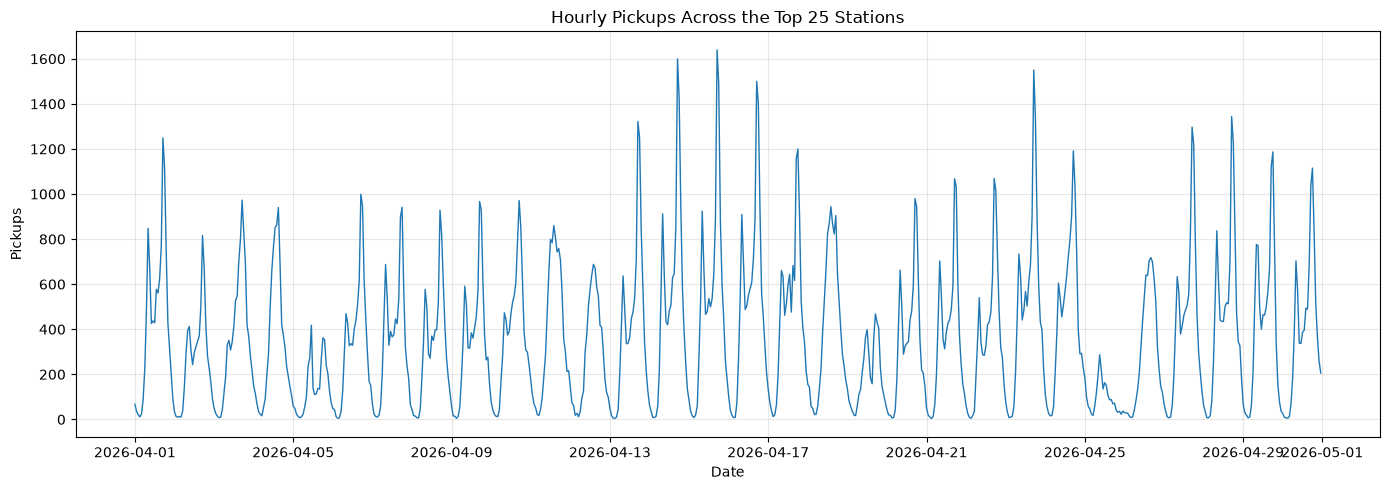

In [4]:
system_hourly = (
    pickups.groupby("timestamp", as_index=False)["pickups"]
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    system_hourly["timestamp"],
    system_hourly["pickups"],
    linewidth=1,
)

ax.set_title("Hourly Pickups Across the Top 25 Stations")
ax.set_xlabel("Date")
ax.set_ylabel("Pickups")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

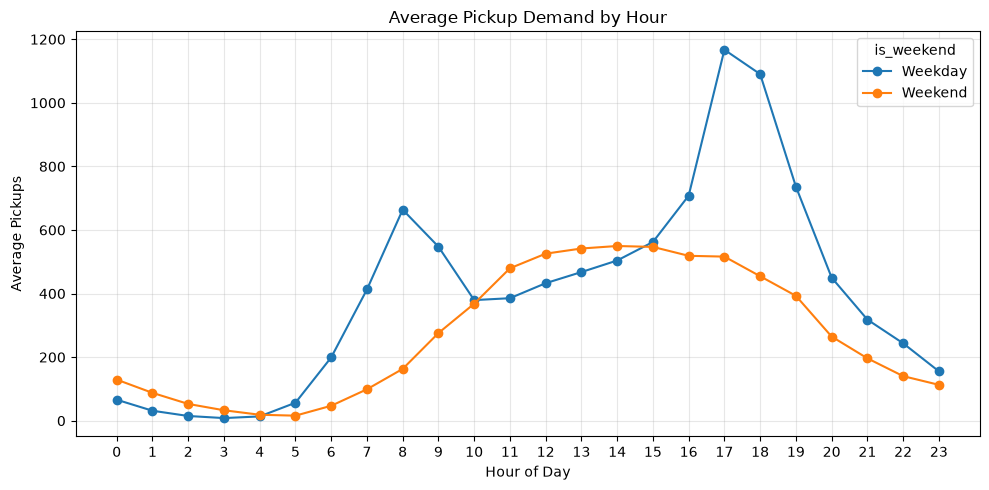

In [5]:
system_hourly["hour"] = system_hourly["timestamp"].dt.hour
system_hourly["is_weekend"] = (
    system_hourly["timestamp"].dt.dayofweek >= 5
)

hourly_profile = (
    system_hourly.groupby(
        ["hour", "is_weekend"]
    )["pickups"]
    .mean()
    .unstack()
    .rename(
        columns={
            False: "Weekday",
            True: "Weekend",
        }
    )
)

ax = hourly_profile.plot(
    figsize=(10, 5),
    marker="o",
)

ax.set_title("Average Pickup Demand by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Pickups")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

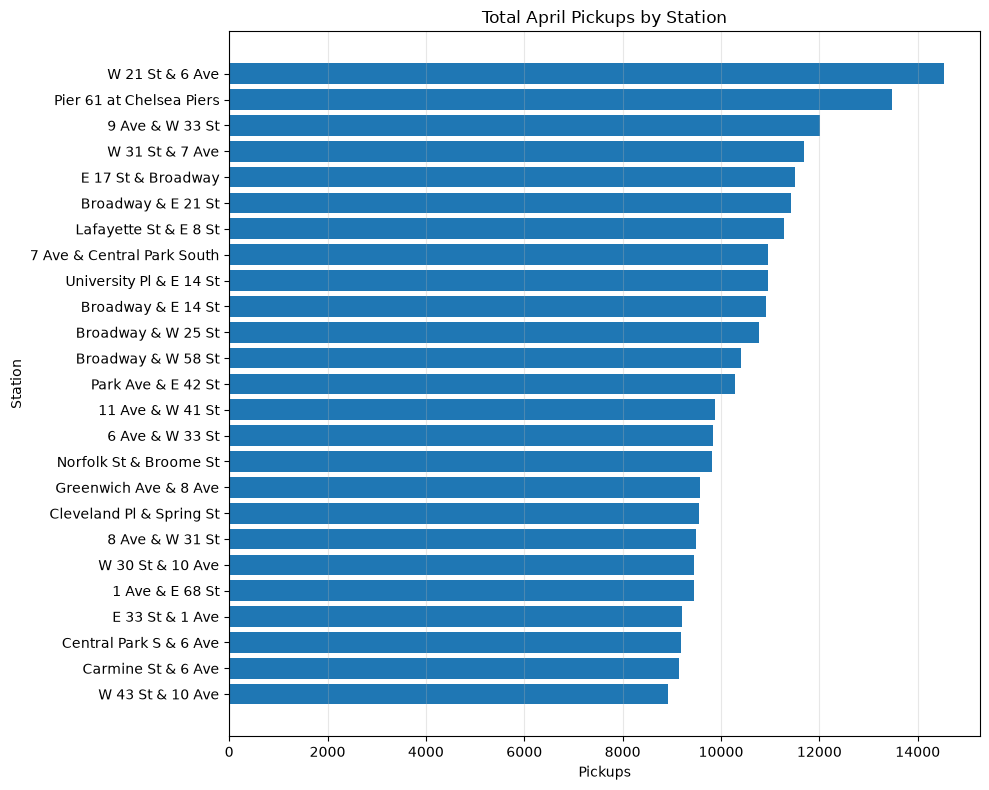

In [6]:
station_totals = (
    pickups.groupby(
        ["station_id", "station_name"],
        as_index=False,
    )["pickups"]
    .sum()
    .sort_values("pickups")
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    station_totals["station_name"],
    station_totals["pickups"],
)

ax.set_title("Total April Pickups by Station")
ax.set_xlabel("Pickups")
ax.set_ylabel("Station")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
METADATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "station_metadata.parquet"
)

station_metadata = pd.read_parquet(METADATA_FILE)

station_map = station_totals.merge(
    station_metadata[
        [
            "station_id",
            "latitude",
            "longitude",
        ]
    ],
    on="station_id",
    how="left",
    validate="one_to_one",
)

print(
    f"Stations missing coordinates: "
    f"{station_map['latitude'].isna().sum()}"
)

fig = px.scatter_map(
    station_map,
    lat="latitude",
    lon="longitude",
    size="pickups",
    color="pickups",
    hover_name="station_name",
    hover_data={
        "station_id": True,
        "pickups": ":,",
        "latitude": False,
        "longitude": False,
    },
    size_max=30,
    zoom=11,
    map_style="open-street-map",
    title="Top 25 Citi Bike Stations by April Pickups",
)

fig.update_layout(
    height=700,
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
)

fig.show()

Stations missing coordinates: 0


In [10]:
NTA_URL = (
    "https://data.cityofnewyork.us/resource/"
    "9nt8-h7nd.geojson?$limit=500"
)

neighborhoods = gpd.read_file(NTA_URL)

print(f"Neighborhood boundaries: {len(neighborhoods)}")
print(neighborhoods.crs)

neighborhoods[
    [
        "boroname",
        "ntaname",
    ]
].head()

Neighborhood boundaries: 262
EPSG:4326


,boroname,ntaname
0,Brooklyn,Greenpoint
1,Brooklyn,Williamsburg
2,Brooklyn,South Williamsburg
3,Brooklyn,East Williamsburg
4,Brooklyn,Brooklyn Heights


In [11]:
station_points = gpd.GeoDataFrame(
    station_map.copy(),
    geometry=gpd.points_from_xy(
        station_map["longitude"],
        station_map["latitude"],
    ),
    crs="EPSG:4326",
)

station_locations = gpd.sjoin(
    station_points,
    neighborhoods[
        [
            "boroname",
            "ntaname",
            "geometry",
        ]
    ],
    how="left",
    predicate="within",
).drop(columns="index_right")

print(
    f"Stations missing neighborhoods: "
    f"{station_locations['ntaname'].isna().sum()}"
)

station_locations[
    [
        "station_name",
        "boroname",
        "ntaname",
        "pickups",
    ]
].sort_values(
    "pickups",
    ascending=False,
).reset_index(drop=True)

Stations missing neighborhoods: 0


,station_name,boroname,ntaname,pickups
0,W 21 St & 6 Ave,Manhattan,Chelsea-Hudson Yards,14539
1,Pier 61 at Chelsea Piers,Manhattan,Chelsea-Hudson Yards,13480
2,9 Ave & W 33 St,Manhattan,Chelsea-Hudson Yards,12003
3,W 31 St & 7 Ave,Manhattan,Midtown South-Flatiron-Union Square,11683
4,E 17 St & Broadway,Manhattan,Midtown South-Flatiron-Union Square,11505
5,Broadway & E 21 St,Manhattan,Midtown South-Flatiron-Union Square,11414
6,Lafayette St & E 8 St,Manhattan,Greenwich Village,11281
7,7 Ave & Central Park South,Manhattan,Midtown-Times Square,10958
8,University Pl & E 14 St,Manhattan,Greenwich Village,10957
9,Broadway & E 14 St,Manhattan,Greenwich Village,10907


## Demand by Neighborhood

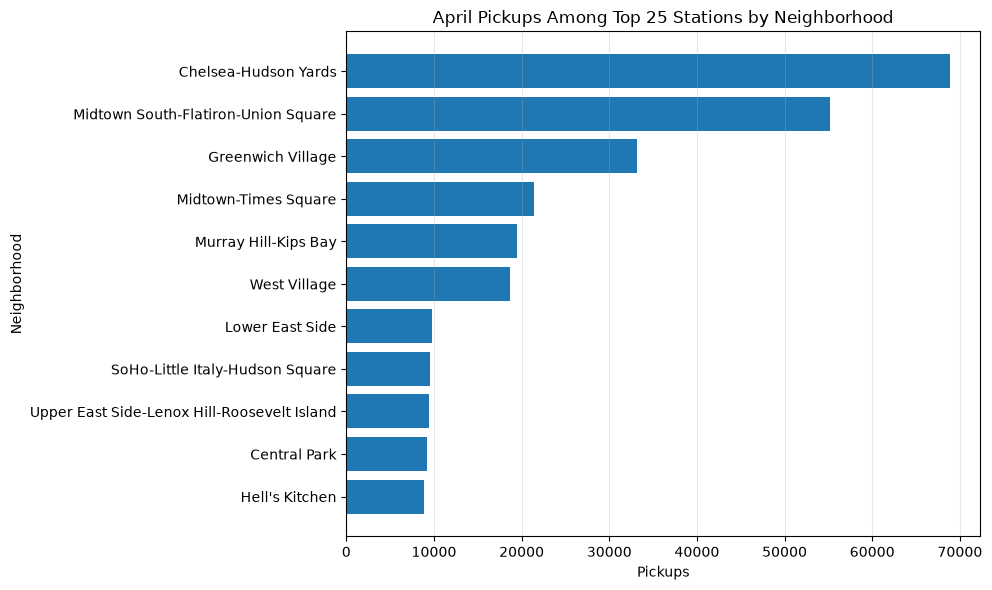

In [13]:
neighborhood_totals = (
    station_locations.groupby(
        ["boroname", "ntaname"],
        as_index=False,
    )["pickups"]
    .sum()
    .sort_values("pickups")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    neighborhood_totals["ntaname"],
    neighborhood_totals["pickups"],
)

ax.set_title(
    "April Pickups Among Top 25 Stations by Neighborhood"
)
ax.set_xlabel("Pickups")
ax.set_ylabel("Neighborhood")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
neighborhood_summary = (
    station_locations.groupby(
        ["boroname", "ntaname"],
        as_index=False,
    )
    .agg(
        selected_stations=("station_id", "nunique"),
        total_pickups=("pickups", "sum"),
        average_pickups_per_station=("pickups", "mean"),
    )
    .sort_values("total_pickups", ascending=False)
)

neighborhood_summary["pickup_share"] = (
    neighborhood_summary["total_pickups"]
    / neighborhood_summary["total_pickups"].sum()
)

neighborhood_summary.style.format(
    {
        "total_pickups": "{:,.0f}",
        "average_pickups_per_station": "{:,.0f}",
        "pickup_share": "{:.1%}",
    }
)

,boroname,ntaname,selected_stations,total_pickups,average_pickups_per_station,pickup_share
1,Manhattan,Chelsea-Hudson Yards,6,"68,852","11,475",26.1%
5,Manhattan,Midtown South-Flatiron-Union Square,5,"55,212","11,042",20.9%
2,Manhattan,Greenwich Village,3,"33,145","11,048",12.6%
6,Manhattan,Midtown-Times Square,2,"21,357","10,678",8.1%
7,Manhattan,Murray Hill-Kips Bay,2,"19,504","9,752",7.4%
10,Manhattan,West Village,2,"18,720","9,360",7.1%
4,Manhattan,Lower East Side,1,"9,827","9,827",3.7%
8,Manhattan,SoHo-Little Italy-Hudson Square,1,"9,561","9,561",3.6%
9,Manhattan,Upper East Side-Lenox Hill-Roosevelt Island,1,"9,451","9,451",3.6%
0,Manhattan,Central Park,1,"9,191","9,191",3.5%


### Initial Findings

- Pickup demand follows a strong daily cycle, with weekday peaks around the morning and evening commutes.
- Weekend demand rises later, remains steadier during the day, and is higher around midnight.
- All 25 selected high-demand stations are located in Manhattan.
- Chelsea-Hudson Yards contributes the most total demand, largely because it contains six of the selected stations.
- Station location and day type will likely be useful inputs for forecasting.